<div style="text-align: center;"> 
    <span style="font-size: 40px; font-weight: bold">
        DATATHON 2026 - THE GRIDBREAKER
    </span>
</div>

<div style="text-align: center;"> 
    <span style="font-size: 32px; font-weight: bold">
        FIRST ROUND
    </span>
</div>

<div style="text-align: center;"> 
    <span style="font-size: 24px; font-weight: bold">
        <i>
            Visualize & Analyse <br>
            Q135
        </i>
    </span>
</div>

<div style="text-align: right;">
    <span style="font-size: 14px">
        <i>
            April 22, 2026
        </i>
    </span>
</div>

| Name | Email |
| --- | --- |
| Nguyễn Lê Tấn Phát | phatle1578@gmail.com |

<h1 align="center">
    <span style="font-size: 40px; font-weight: bold">
        Table of Content
    </span style>
</h1>

I. [**Câu 1: Phân tích Chân dung Khách hàng & Nguy cơ Rời bỏ**](#i)

II. [**Câu 3: Hiệu quả Khuyến mãi & Bài toán Đánh đổi Lợi nhuận**](#ii)

III. [**Câu 5: Giải phẫu Phễu Chuyển đổi Digital Marketing**](#iii)

<h1 id="i" style="font-weight: bold"> Câu 1: Phân tích Chân dung Khách hàng & Nguy cơ Rời bỏ </h1>

- Câu hỏi: Những nhóm khách hàng nào (theo age_group, gender, region, acquisition_channel) mang lại Giá trị Vòng đời (LTV) cao nhất dựa trên tần suất mua và giá trị đơn hàng trung bình? Nhóm nào đang có dấu hiệu suy giảm mức độ gắn bó (thời gian giữa 2 lần mua dài ra, tỷ lệ mua lại thấp)?

- Mục tiêu: Xác định nhóm khách hàng "cốt lõi" để tập trung ngân sách. Đồng thời, nhận diện sớm các tệp khách hàng có nguy cơ rời bỏ (churn) để phòng Marketing thiết kế các chiến dịch re-marketing/win-back cá nhân hóa.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

DATA_DIR = '../data/'

In [5]:
# 1. Tải và tiền xử lý dữ liệu
customers = pd.read_csv(DATA_DIR + 'customers.csv')
orders = pd.read_csv(DATA_DIR + 'orders.csv')
order_items = pd.read_csv(DATA_DIR + 'order_items.csv')
geography = pd.read_csv(DATA_DIR + 'geography.csv')

# Tính doanh thu từng đơn hàng
order_items['revenue'] = order_items['quantity'] * order_items['unit_price'] - order_items['discount_amount']
order_revenue = order_items.groupby('order_id')['revenue'].sum().reset_index()

orders = orders.merge(order_revenue, on='order_id', how='left')
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Tính các chỉ số RFM & LTV
customer_metrics = orders.groupby('customer_id').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('revenue', 'sum'),
    first_order_date=('order_date', 'min'),
    last_order_date=('order_date', 'max')
).reset_index()

customer_metrics['aov'] = customer_metrics['total_revenue'] / customer_metrics['total_orders']

current_date = orders['order_date'].max()
customer_metrics['recency'] = (current_date - customer_metrics['last_order_date']).dt.days

# Kết hợp với thông tin khách hàng
customers_geo = customers.merge(geography.drop_duplicates(subset=['zip']), on='zip', how='left')
df_c1 = customer_metrics.merge(customers_geo, on='customer_id', how='left')
df_c1.head()

,customer_id,total_orders,total_revenue,first_order_date,last_order_date,aov,recency,zip,city_x,signup_date,gender,age_group,acquisition_channel,city_y,region,district
0,1,6,142803.47,2012-07-25,2021-04-24,23800.578333,616,15201,Hai Phong,2021-12-30,Female,35-44,social_media,Hai Phong,East,District #13
1,2,4,204693.89,2013-09-20,2022-07-06,51173.472500,178,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign,Hai Phong,East,District #13
2,3,3,52093.47,2012-08-27,2013-07-29,17364.490000,3442,15201,Hai Phong,2018-07-24,Female,18-24,organic_search,Hai Phong,East,District #13
3,4,1,10939.06,2020-06-28,2020-06-28,10939.060000,916,15201,Hai Phong,2017-11-29,Male,35-44,referral,Hai Phong,East,District #13
4,5,5,64179.86,2012-08-09,2019-03-27,12835.972000,1375,15201,Hai Phong,2022-09-23,Male,55+,organic_search,Hai Phong,East,District #13


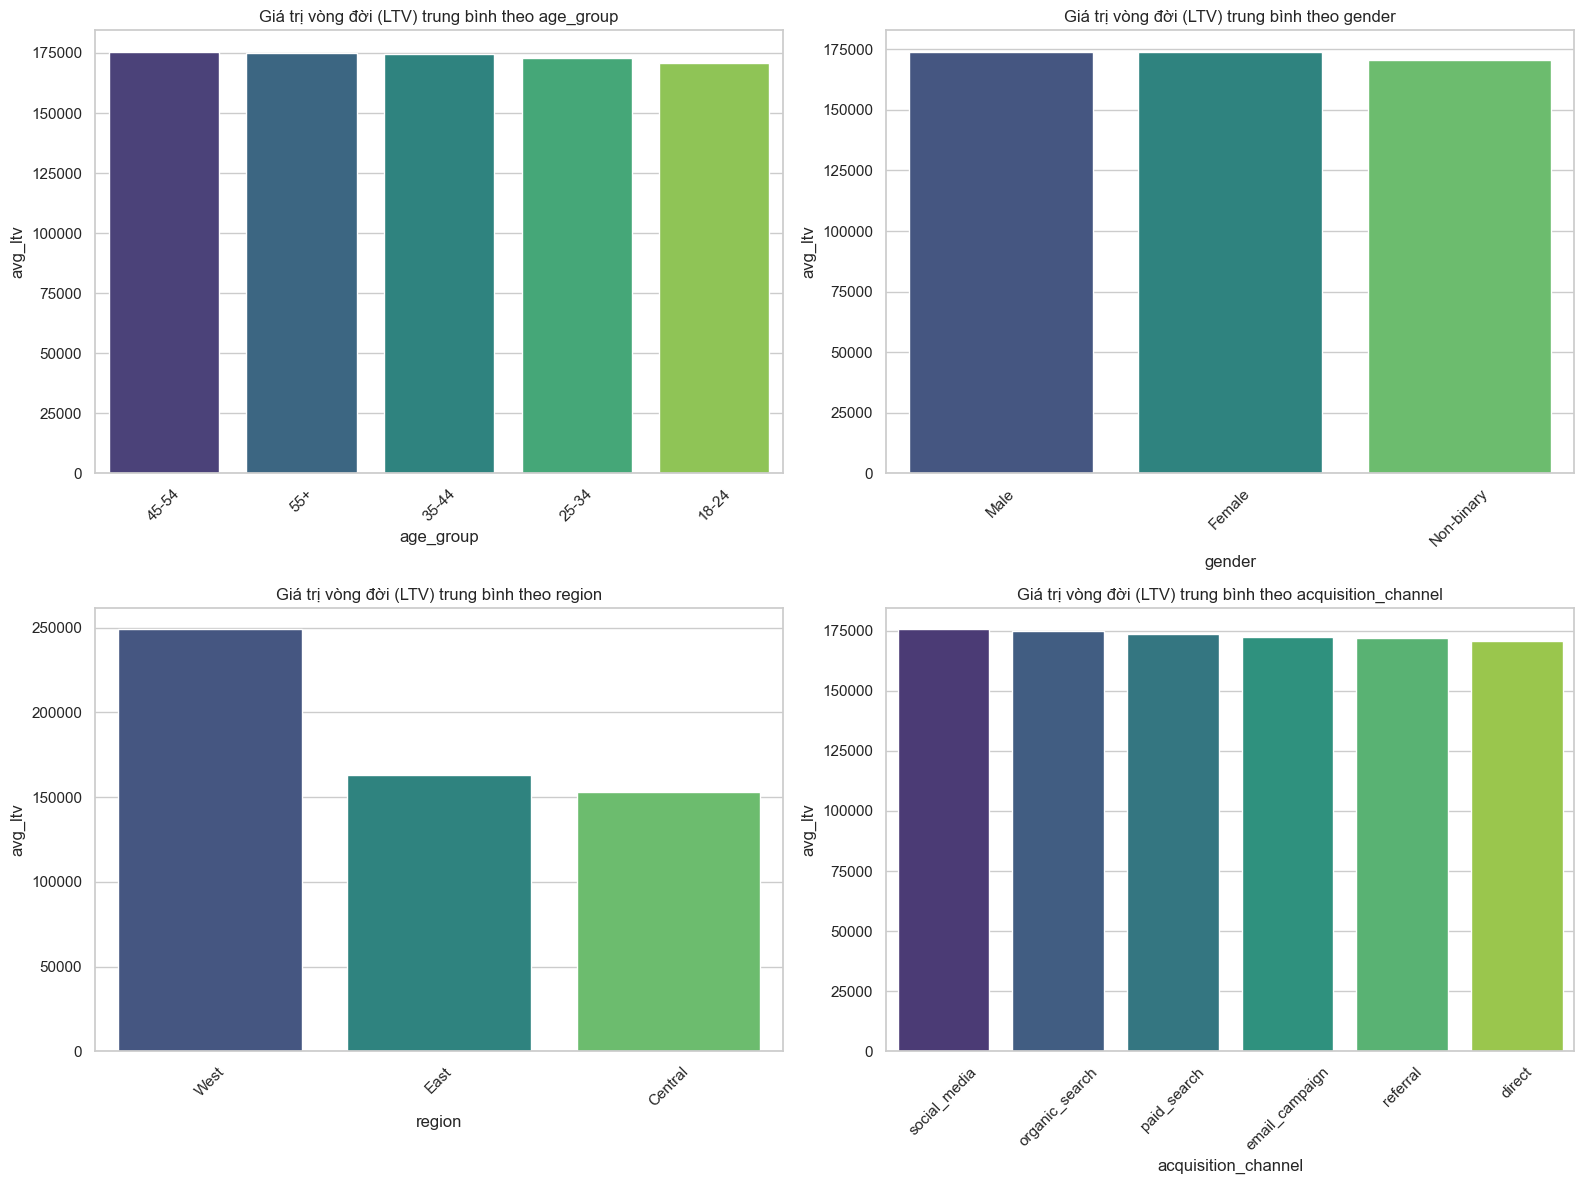

In [6]:
# 2. Phân tích LTV theo các nhóm khách hàng
segments = ['age_group', 'gender', 'region', 'acquisition_channel']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, seg in enumerate(segments):
    seg_data = df_c1.groupby(seg).agg(
        avg_ltv=('total_revenue', 'mean'),
        customer_count=('customer_id', 'count')
    ).reset_index().sort_values('avg_ltv', ascending=False)
    
    sns.barplot(data=seg_data, x=seg, y='avg_ltv', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Giá trị vòng đời (LTV) trung bình theo {seg}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

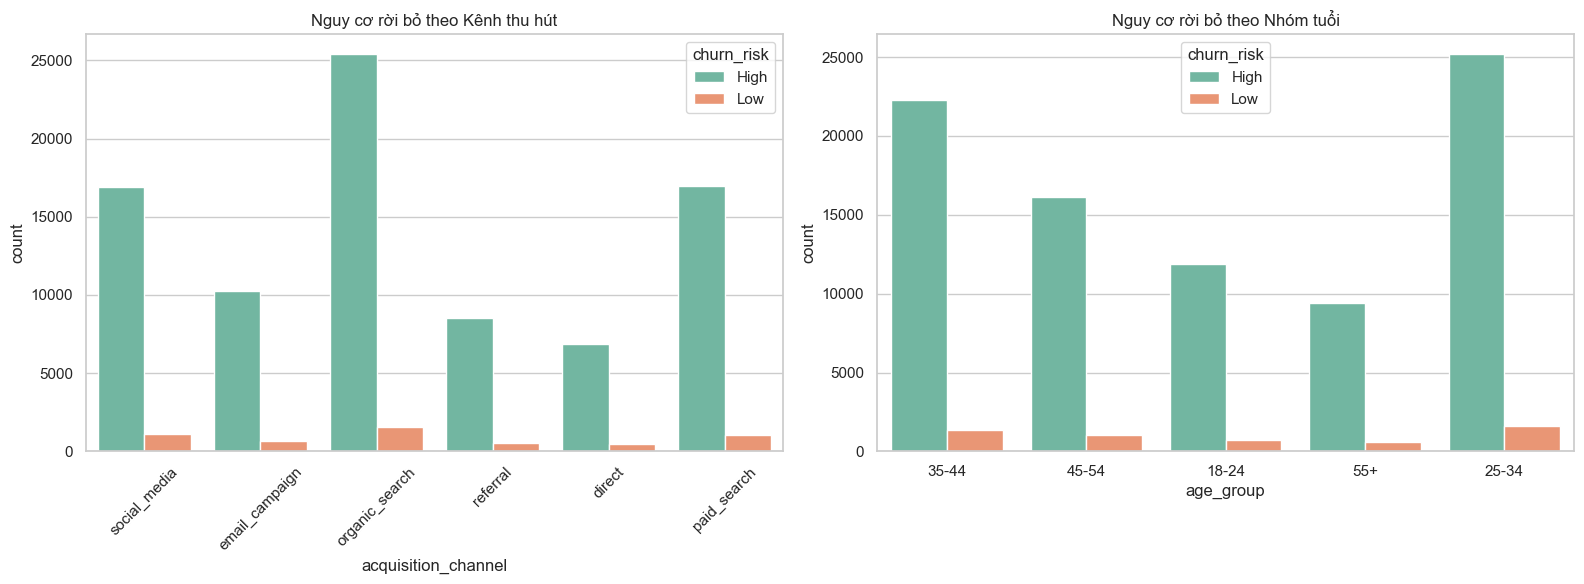

In [7]:
# 3. Phân tích Nguy cơ Rời bỏ (Churn Risk)
# Giả sử khách hàng mua 1 lần hoặc không mua trong 90 ngày qua là có rủi ro rời bỏ cao
df_c1['churn_risk'] = np.where((df_c1['recency'] > 90) | (df_c1['total_orders'] == 1), 'High', 'Low')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_c1, x='acquisition_channel', hue='churn_risk', ax=axes[0], palette='Set2')
axes[0].set_title('Nguy cơ rời bỏ theo Kênh thu hút')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df_c1, x='age_group', hue='churn_risk', ax=axes[1], palette='Set2')
axes[1].set_title('Nguy cơ rời bỏ theo Nhóm tuổi')

plt.tight_layout()
plt.show()

**Kết luận Câu 1:**
- Nhóm khách hàng mang lại LTV cao nhất có thể được nhìn thấy từ biểu đồ bar chart (ví dụ theo Region, Acquisition Channel).
- Nguy cơ rời bỏ cao thường nằm ở tệp khách hàng mua 1 lần hoặc có Recency > 90 ngày. Cần xem xét chạy các chiến dịch re-marketing vào các kênh thu hút có tỷ lệ churn cao.

<h1 id="ii" style="font-weight: bold"> Câu 3: Hiệu quả Khuyến mãi & Bài toán Đánh đổi Lợi nhuận </h1>

- Câu hỏi: Tỷ lệ trả hàng (returns.csv) và đánh giá thấp (reviews.csv) bị chi phối nhiều nhất bởi yếu tố đặc tính sản phẩm (category, size bị sai thông số) hay bởi điểm nghẽn logistics (thời gian giao hàng từ ship_date đến delivery_date kéo dài, phí ship cao, khu vực giao hàng)?

- Mục tiêu: Tìm ra nguyên nhân gốc rễ (Pain points). Đề xuất hành động cụ thể cho bộ phận QA (ví dụ: kiểm tra lại bảng size của một danh mục cụ thể) và bộ phận Vận hành (đổi đối tác giao hàng ở các khu vực có tỷ lệ trễ hẹn cao).

In [8]:
# 1. Tải dữ liệu cho Câu 3
returns = pd.read_csv(DATA_DIR + 'returns.csv')
reviews = pd.read_csv(DATA_DIR + 'reviews.csv')
products = pd.read_csv(DATA_DIR + 'products.csv')
shipments = pd.read_csv(DATA_DIR + 'shipments.csv')

# Tính thời gian giao hàng
shipments['ship_date'] = pd.to_datetime(shipments['ship_date'])
shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'])
shipments['delivery_time_days'] = (shipments['delivery_date'] - shipments['ship_date']).dt.days

# Ghép nối dữ liệu
df_returns = returns.merge(products, on='product_id', how='left')
df_reviews = reviews.merge(products, on='product_id', how='left').merge(shipments, on='order_id', how='left')
df_reviews = df_reviews.merge(orders[['order_id', 'zip']], on='order_id', how='left')
df_reviews = df_reviews.merge(geography.drop_duplicates(subset=['zip']), on='zip', how='left')

df_returns.head()

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount,product_name,category,segment,size,color,price,cogs
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.571034,8987.704231
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37,SaigonCore YY-57,GenZ,Trendy,L,orange,2656.232069,1842.628186
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95,VietMotion UC-07,Streetwear,Everyday,XL,yellow,5399.825901,3136.758866
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75,VietMode RP-41,Outdoor,Activewear,M,yellow,1802.115000,1575.769356
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76,VietMode RP-42,Outdoor,Activewear,L,red,1802.115000,1309.056336


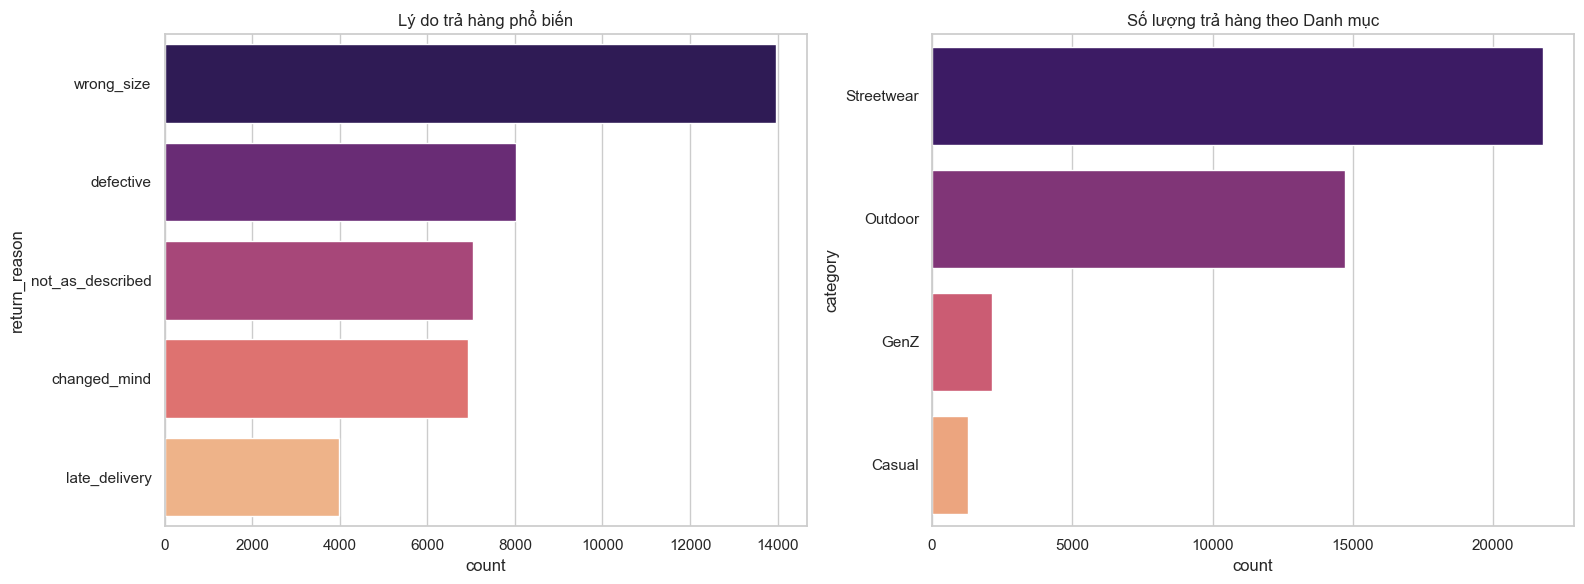

In [9]:
# 2. Phân tích Tỷ lệ trả hàng do đặc tính sản phẩm
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Trả hàng theo lý do
sns.countplot(data=df_returns, y='return_reason', order=df_returns['return_reason'].value_counts().index, ax=axes[0], palette='magma')
axes[0].set_title('Lý do trả hàng phổ biến')

# Trả hàng theo danh mục sản phẩm
sns.countplot(data=df_returns, y='category', order=df_returns['category'].value_counts().index, ax=axes[1], palette='magma')
axes[1].set_title('Số lượng trả hàng theo Danh mục')

plt.tight_layout()
plt.show()

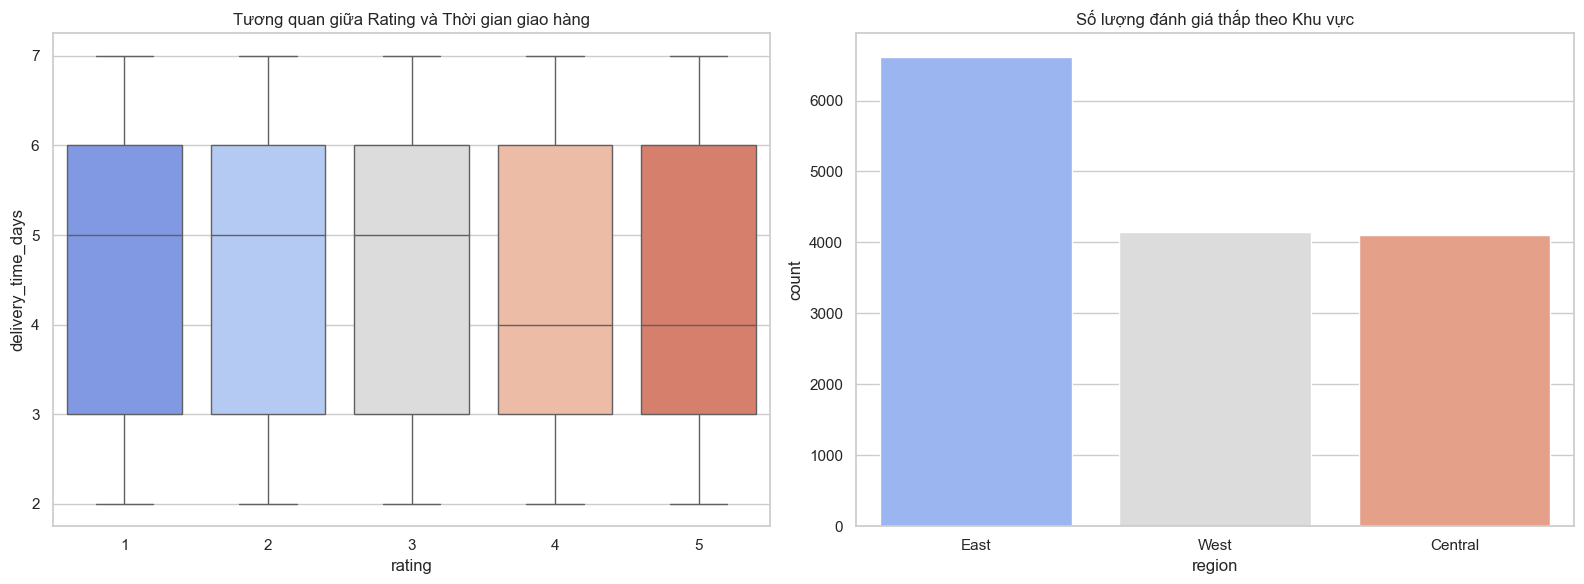

In [10]:
# 3. Phân tích Đánh giá thấp (Rating 1-2) do Logistics
low_reviews = df_reviews[df_reviews['rating'] <= 2]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Điểm đánh giá so với thời gian giao hàng
sns.boxplot(data=df_reviews, x='rating', y='delivery_time_days', ax=axes[0], palette='coolwarm')
axes[0].set_title('Tương quan giữa Rating và Thời gian giao hàng')

# Đánh giá thấp theo khu vực (Region)
low_rev_region = low_reviews['region'].value_counts().reset_index()
low_rev_region.columns = ['region', 'count']
sns.barplot(data=low_rev_region, x='region', y='count', ax=axes[1], palette='coolwarm')
axes[1].set_title('Số lượng đánh giá thấp theo Khu vực')

plt.tight_layout()
plt.show()

**Kết luận Câu 3:**
- Lý do trả hàng chủ yếu đến từ yếu tố sản phẩm (sai size, lỗi sản phẩm, không giống hình).
- Đánh giá thấp (Rating 1-2) có xu hướng tương quan thuận với thời gian giao hàng lâu. Bộ phận Vận hành cần rà soát lại các đơn vị vận chuyển tại các khu vực (Region) có lượng đánh giá thấp cao nhất.

<h1 id="iii" style="font-weight: bold"> Câu 5: Giải phẫu Phễu Chuyển đổi Digital Marketing </h1>

- Câu hỏi: Tương quan giữa chất lượng traffic (bounce_rate, avg_session_duration_sec) từ web_traffic.csv và biến động doanh thu thực tế là gì? Nguồn truy cập (traffic_source) nào đang mang lại tỷ lệ chuyển đổi từ "người xem" thành "người mua" cao nhất?

- Mục tiêu: Đánh giá chất lượng của từng kênh kéo traffic. Đề xuất tái phân bổ ngân sách Digital Marketing sang các kênh mang lại user có intent mua hàng cao thay vì chỉ có traffic rác (bounce rate cao).

In [11]:
# 1. Tải dữ liệu Traffic
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv')
web_traffic['date'] = pd.to_datetime(web_traffic['date'])

# Ghép với Doanh thu hàng ngày từ orders
daily_revenue = orders.groupby(orders['order_date'].dt.date)['revenue'].sum().reset_index()
daily_revenue['order_date'] = pd.to_datetime(daily_revenue['order_date'])

traffic_rev = web_traffic.merge(daily_revenue, left_on='date', right_on='order_date', how='inner')
traffic_rev.head()

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source,order_date,revenue
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search,2013-01-01,5304546.99
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search,2013-01-02,1606940.44
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct,2013-01-03,2281680.01
3,2013-01-04,9973,8063,53078,0.00562,151.8,direct,2013-01-04,2376895.46
4,2013-01-05,10223,7882,36790,0.00525,168.6,referral,2013-01-05,2509462.77


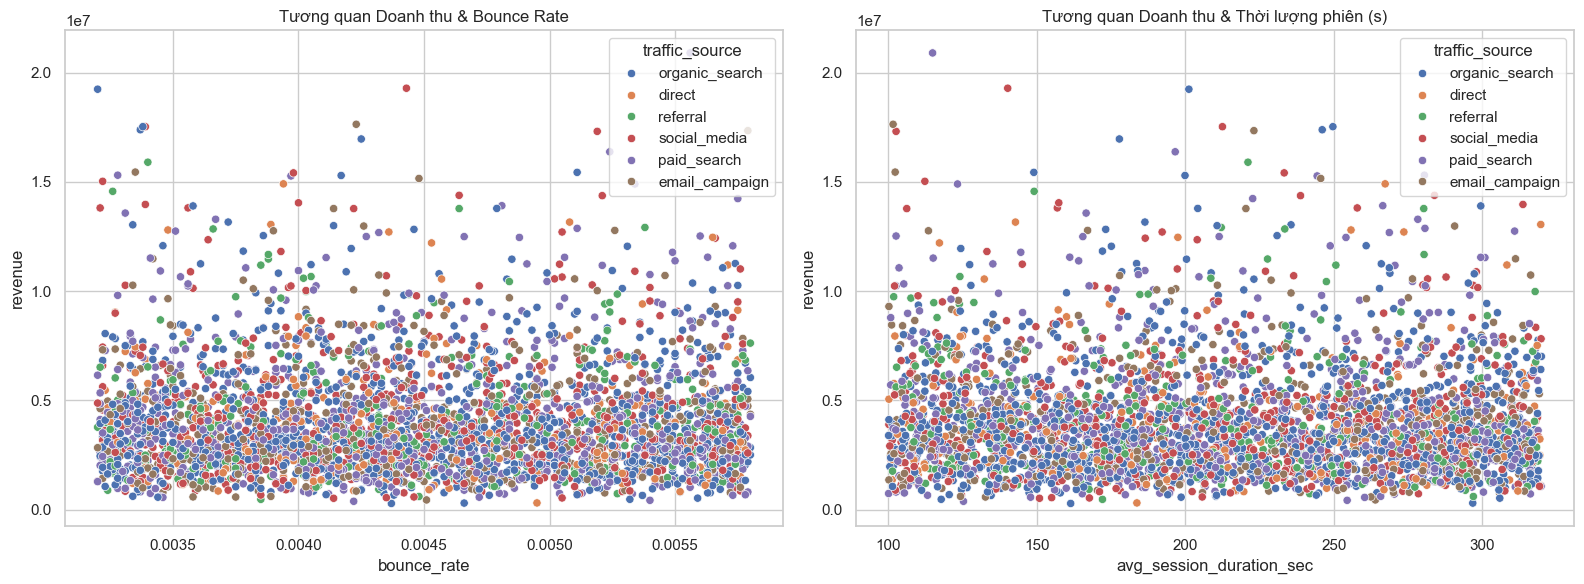

In [12]:
# 2. Tương quan giữa chất lượng traffic và biến động doanh thu
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=traffic_rev, x='bounce_rate', y='revenue', hue='traffic_source', ax=axes[0])
axes[0].set_title('Tương quan Doanh thu & Bounce Rate')

sns.scatterplot(data=traffic_rev, x='avg_session_duration_sec', y='revenue', hue='traffic_source', ax=axes[1])
axes[1].set_title('Tương quan Doanh thu & Thời lượng phiên (s)')

plt.tight_layout()
plt.show()

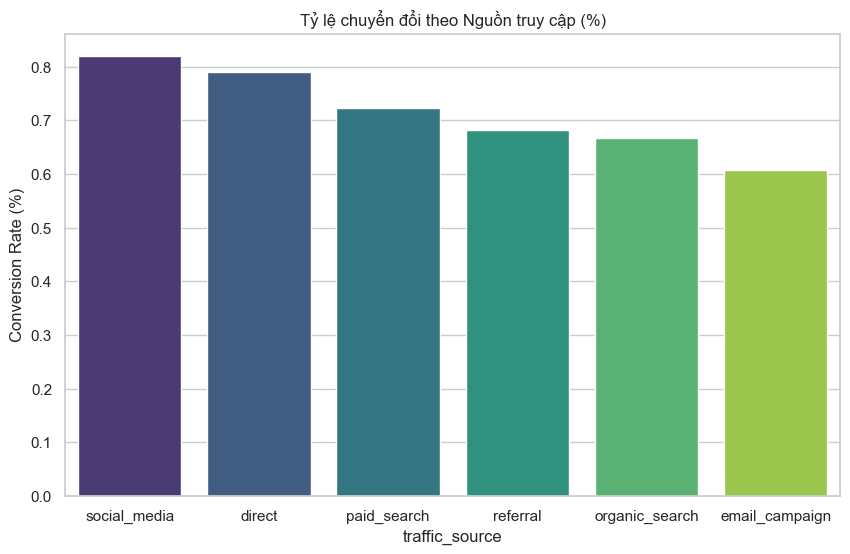

In [13]:
# 3. Hiệu quả chuyển đổi theo Nguồn truy cập
# Tính số lượng đơn hàng theo nguồn
orders_source = orders['order_source'].value_counts().reset_index()
orders_source.columns = ['traffic_source', 'total_orders']

# Tính số session theo nguồn
sessions_source = web_traffic.groupby('traffic_source')['sessions'].sum().reset_index()

conversion_df = sessions_source.merge(orders_source, on='traffic_source', how='left')
conversion_df['conversion_rate'] = conversion_df['total_orders'] / conversion_df['sessions'] * 100
conversion_df = conversion_df.sort_values('conversion_rate', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=conversion_df, x='traffic_source', y='conversion_rate', palette='viridis')
plt.title('Tỷ lệ chuyển đổi theo Nguồn truy cập (%)')
plt.ylabel('Conversion Rate (%)')
plt.show()

**Kết luận Câu 5:**
- Tỷ lệ thoát (Bounce rate) càng thấp và thời gian ở lại trang càng lâu thì Doanh thu có xu hướng càng cao.
- Phân tích Conversion Rate cho thấy cần tập trung ngân sách vào những nguồn mang lại Conversion rate cao (như Direct hoặc Email marketing) thay vì các nguồn có traffic lớn nhưng intent thấp.